In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv("./data/forbes_and_yahoo_738.csv")


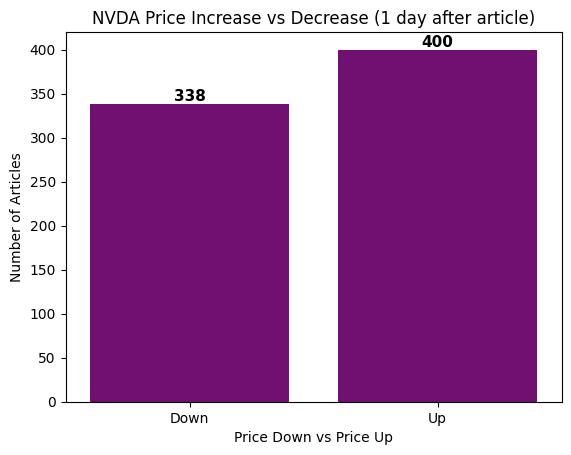

0.45799457994579945
0.5420054200542005


In [2]:
#dataframe
df['Price_Up_1D'] = (df['T+1D'] > df['T-0D']).astype(int)

ax = sns.countplot(x='Price_Up_1D', data=df, color="purple")
plt.title('NVDA Price Increase vs Decrease (1 day after article)')
plt.xlabel('Price Down vs Price Up')
plt.ylabel('Number of Articles')

ax.set_xticks([0, 1])
ax.set_xticklabels(['Down', 'Up'])

#label on bars
for i, bar in enumerate(ax.patches):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    
plt.savefig("incVsDec.png")

plt.show()

# % of each
print(338/738) #dec
print(400/738) #inc

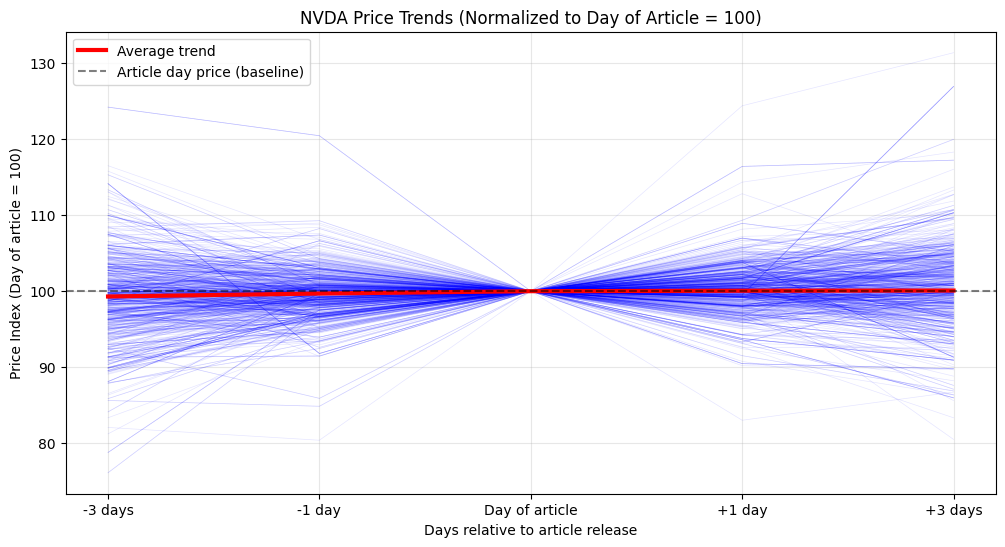

Averages: 
1 day after: 0.06%
3 days after: 0.08%
0.7862245028067303 %


In [3]:
price_cols = ['T-3D', 'T-1D', 'T-0D', 'T+1D', 'T+3D']
days_labels = ['-3 days', '-1 day', 'Day of article', '+1 day', '+3 days']

plt.figure(figsize=(12, 6))

for i in range(len(df)):
    prices = df[price_cols].iloc[i].values

    # normalize to T-0D = 100 for readability
    prices_norm = (prices / prices[2]) * 100 
    plt.plot(days_labels, prices_norm, color='blue', alpha=0.1, linewidth=0.5)

#avg trendline
avg_prices = df[price_cols].mean()
t0_baseline = avg_prices['T-0D']
avg_norm = (avg_prices / t0_baseline) * 100
plt.plot(days_labels, avg_norm, color='red', linewidth=3, label='Average trend')

plt.axhline(y=100, color='black', linestyle='--', alpha=0.5, label='Article day price (baseline)')
plt.title('NVDA Price Trends (Normalized to Day of Article = 100)')
plt.ylabel('Price Index (Day of article = 100)')
plt.xlabel('Days relative to article release')
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig("priceTrends.png")

plt.show()

# averages
print("Averages: ")
print(f"1 day after: {(avg_prices['T+1D']/avg_prices['T-0D'] - 1)*100:.2f}%")
print(f"3 days after: {(avg_prices['T+3D']/avg_prices['T-0D'] - 1)*100:.2f}%")

print(((df['T+3D'].mean() - df['T-3D'].mean()) / df['T-3D'].mean()) * 100, "%") #avg change

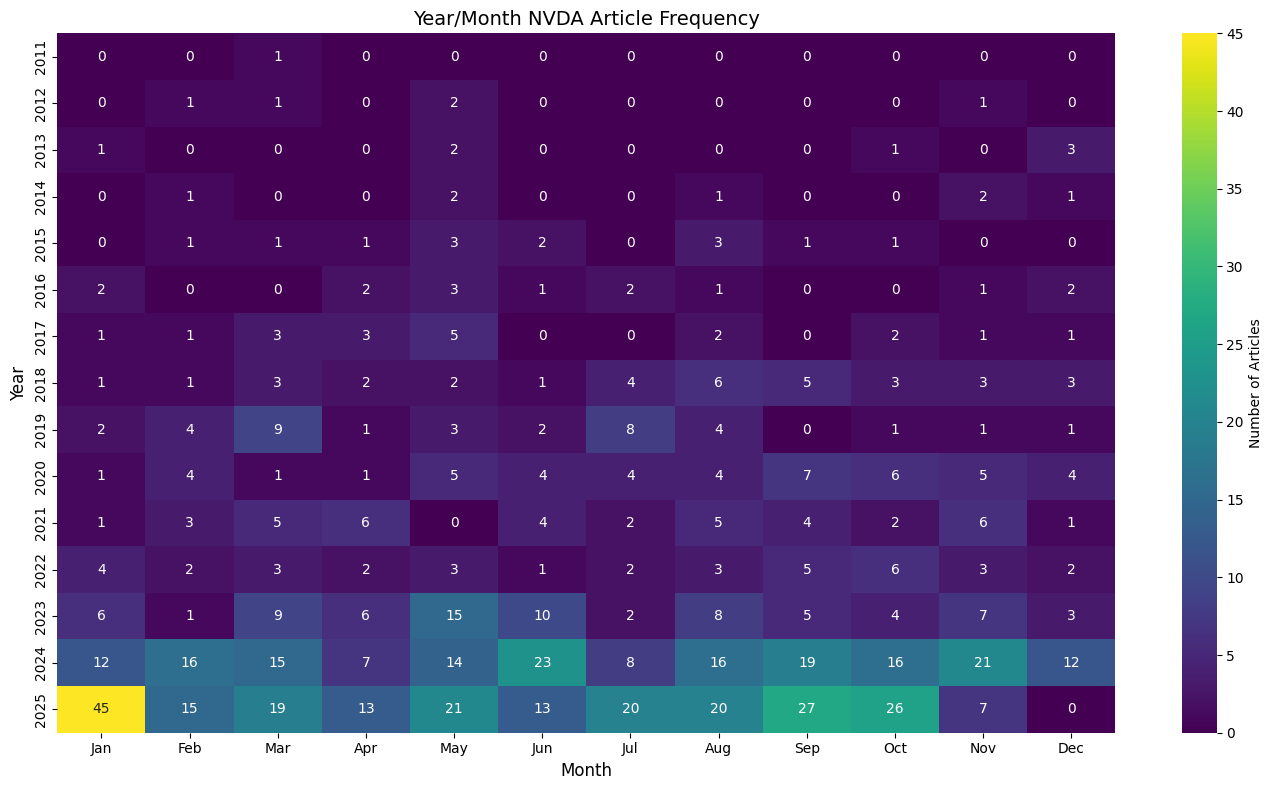

In [4]:
df['Year'] = df['Time'].str.extract(r'(\d{4})').astype(int)

month = df['Time'].str[:3]

#month -> number
month_map = {
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6,
    'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
}
df['Month'] = month.map(month_map)

# table 4 heatmap
monthly_counts = df.groupby(['Year', 'Month']).size().unstack(fill_value=0)

plt.figure(figsize=(14, 8))
sns.heatmap(monthly_counts, annot=True, fmt='d', cmap='viridis', 
            cbar_kws={'label': 'Number of Articles'})
plt.title('Year/Month NVDA Article Frequency', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Year', fontsize=12)

# Rename months
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

plt.xticks(ticks=np.arange(12) + 0.5, labels=month_names)

plt.tight_layout()

plt.savefig("freqHeatmap.png")

plt.show()